# 03. LightGBM 베이스라인

**목표**: 앞으로 모든 개선을 비교할 **기준점(baseline) CV 점수**를 만든다.

베이스라인은 화려할 필요가 없다. 오히려 **단순해야 한다.**
"파생변수도 없고 튜닝도 안 한 상태에서 몇 점인가"를 알아야,
나중에 04단계에서 "내가 만든 피처가 진짜 도움이 됐는가"를 판단할 수 있다.

### 이 노트북에서 할 일
1. LightGBM 베이스라인 5-Fold CV AUC 측정
2. 02단계에서 남겨둔 숙제 — **결측 처리 전략 A/B/C/D 실측 비교**
3. 피처 중요도 확인 → 04단계 파생변수 설계의 근거 확보
4. OOF 예측 저장 → 05단계 앙상블에서 사용

## 0. 준비

In [1]:
import sys
sys.path.append('../src')

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import roc_auc_score, roc_curve

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)

SEED = 42
np.random.seed(SEED)

from preprocess import (load_data, to_category, align_categories, impute_median,
                        NUM_COLS, CAT_COLS, TARGET)
from cv import get_folds, run_cv, ExperimentLog

train, test, sub = load_data('../data/')
y = train[TARGET].values

# 02단계에서 정한 전처리: category dtype + train/test 카테고리 정렬
X, X_test = align_categories(
    to_category(train[NUM_COLS + CAT_COLS]),
    to_category(test[NUM_COLS + CAT_COLS]),
)

# 폴드도 02단계와 동일하게 고정 — 이래야 실험 간 점수 비교가 성립한다
folds = get_folds(X, y, n_splits=5, seed=SEED)

print(f'X {X.shape} / X_test {X_test.shape} / 폴드 {len(folds)}개')

X (691369, 12) / X_test (296302, 12) / 폴드 5개


## 1. LightGBM이란

**LightGBM**(Light Gradient Boosting Machine)은 마이크로소프트가 만든
**그래디언트 부스팅** 라이브러리다. 정형 데이터 대회에서 사실상 표준이다.

### 부스팅(Boosting)의 아이디어
얕은 결정트리(약한 모델)를 **순차적으로** 만들되,
각 트리가 **직전 트리들이 틀린 부분**을 집중적으로 고친다.

```
트리1: 대충 예측    →  틀린 정도(잔차) 계산
트리2: 트리1의 잔차를 예측  →  남은 잔차 계산
트리3: 남은 잔차를 예측  →  ...
최종 예측 = 트리1 + 트리2 + 트리3 + ...
```

혼자서는 못 푸는 문제를 여러 명이 릴레이로 고쳐 나가는 것과 같다.

### 왜 이 대회에 적합한가
- 결측치를 **채우지 않고** 그대로 학습할 수 있다 (02단계 선택지 A)
- 범주형을 **원-핫 없이** `category` dtype으로 바로 처리한다
- 69만 행 정도는 몇십 초 만에 학습한다
- 스케일링이 필요 없다

In [2]:
# 베이스라인 하이퍼파라미터 — 각 값이 무슨 뜻인지 알아두면 04단계 튜닝이 쉬워진다
LGB_PARAMS = dict(
    objective='binary',      # 이진 분류 문제
    metric='auc',            # 조기 종료 판단 기준 (대회 평가 지표와 맞춤)

    learning_rate=0.05,      # 학습률. 트리 하나가 결과를 얼마나 세게 바꿀지.
                             #   작을수록 정교하지만 트리가 많이 필요하다.
    num_leaves=63,           # 트리 하나의 최대 잎(말단 노드) 개수 = 모델 복잡도.
                             #   클수록 표현력↑ 과적합 위험↑
    min_child_samples=50,    # 잎 하나에 최소 몇 개 행이 있어야 하는지.
                             #   너무 작으면 노이즈까지 외운다(과적합)
    feature_fraction=0.8,    # 트리마다 변수의 80%만 무작위로 사용 → 다양성 확보
    bagging_fraction=0.8,    # 트리마다 행의 80%만 무작위로 사용 → 과적합 억제
    bagging_freq=1,          # 매 반복마다 배깅 수행

    n_estimators=3000,       # 최대 트리 개수 (조기 종료로 실제로는 더 적게 씀)
    verbose=-1,              # 학습 로그 끄기
    n_jobs=-1,               # CPU 코어 전부 사용
    random_state=SEED,       # 재현성
)

# 조기 종료(early stopping): 검증 점수가 100번 연속 안 좋아지면 학습을 멈춘다.
# 트리를 무한정 늘리면 학습 데이터만 외우게 되므로(과적합), 최적 지점에서 끊는다.
FIT_PARAMS = dict(
    eval_metric='auc',
    callbacks=[lgb.early_stopping(100, verbose=False)],
)

print('하이퍼파라미터 설정 완료')

하이퍼파라미터 설정 완료


## 2. 베이스라인 CV 측정

In [3]:
# run_cv()는 src/cv.py에 있다. 폴드마다 새 모델을 만들어 학습하고,
# OOF(Out-Of-Fold) 예측과 테스트 예측 평균을 함께 반환한다.
# ⏱ 5폴드 전체에 약 5~8분 소요
base = run_cv(
    model_fn=lambda: lgb.LGBMClassifier(**LGB_PARAMS),
    X=X, y=y, X_test=X_test, folds=folds,
    name='baseline_lgbm', fit_params=FIT_PARAMS,
)

  fold 1/5  AUC=0.962695


  fold 2/5  AUC=0.963585


  fold 3/5  AUC=0.963889


  fold 4/5  AUC=0.964378


  fold 5/5  AUC=0.963330


[baseline_lgbm] CV AUC = 0.963574 (폴드 평균 0.963576 ± 0.000562) | 194.6s


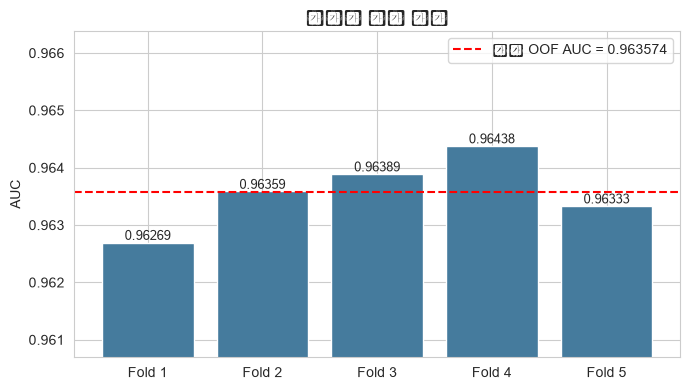

폴드 평균 0.963576 ± 0.000562
최고-최저 차이: 0.001683
평균 사용 트리 수: 1761


In [4]:
# 폴드별 점수가 고르게 나왔는지 확인한다.
# 편차가 크면 "검증이 불안정하다"는 뜻이라 점수를 믿기 어렵다.
scores = base['fold_scores']

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([f'Fold {i}' for i in range(1, len(scores)+1)], scores, color='#457b9d')
ax.axhline(base['cv_auc'], color='red', ls='--', lw=1.5,
           label=f"전체 OOF AUC = {base['cv_auc']:.6f}")
ax.set_ylim(min(scores) - 0.002, max(scores) + 0.002)
ax.set_ylabel('AUC')
ax.set_title('폴드별 검증 점수')
for i, v in enumerate(scores):
    ax.text(i, v, f'{v:.5f}', ha='center', va='bottom', fontsize=9)
ax.legend()
plt.tight_layout(); plt.show()

print(f"폴드 평균 {base['fold_mean']:.6f} ± {base['fold_std']:.6f}")
print(f"최고-최저 차이: {max(scores)-min(scores):.6f}")
print(f"평균 사용 트리 수: {int(np.mean(base['best_iters']))}")

> **OOF AUC vs 폴드 평균 AUC — 뭐가 다른가**
>
> - **폴드 평균**: 각 폴드에서 잰 AUC 5개의 산술평균
> - **OOF AUC**: 5개 폴드의 예측을 전부 이어붙여 **한 번에** 계산한 AUC
>
> 보통 둘은 거의 같지만, **OOF AUC를 기준으로 삼는 게 맞다.**
> 앙상블 가중치를 찾을 때도 OOF 예측을 쓰기 때문에 기준을 통일해야 한다.

## 3. 결측 처리 전략 실측 비교

02단계에서 "CV로 비교해야 안다"고 미뤄둔 숙제를 지금 푼다.

여기서는 **탐색용 고속 설정**(`learning_rate=0.1`, `num_leaves=31`)을 쓴다.
절대 점수는 베이스라인보다 조금 낮지만, **전략 간 순위를 보는 데는 충분**하고
시간이 3배 빠르다. 캐글에서 실험을 많이 돌리려면 이런 요령이 필요하다.

In [5]:
# 탐색용 고속 설정
FAST_PARAMS = dict(LGB_PARAMS)
FAST_PARAMS.update(learning_rate=0.1, num_leaves=31, n_estimators=1500)
FAST_FIT = dict(eval_metric='auc',
                callbacks=[lgb.early_stopping(80, verbose=False)])

def quick_cv(X_variant, name):
    r = run_cv(lambda: lgb.LGBMClassifier(**FAST_PARAMS),
               X_variant, y, folds=folds, name=name,
               fit_params=FAST_FIT, verbose=False)
    print(f'{name:32s} AUC = {r["cv_auc"]:.6f}  (열 {X_variant.shape[1]}개)')
    return r

log = ExperimentLog()

In [6]:
# ── A: 원본 그대로 (LightGBM 자체 결측 처리) ──
rA = quick_cv(X, 'A. 원본 유지')
log.add('A. 원본 유지', rA['cv_auc'], 'LGBM 자체 결측 처리')

A. 원본 유지                         AUC = 0.962750  (열 12개)


In [7]:
# ── B: 중앙값/최빈값 대치 ──
# ⚠️ 엄밀하게는 폴드 안에서 대치값을 계산해야 하지만, 여기서는 전략 비교가 목적이라
#    전체 기준으로 계산한다. 이 데이터는 결측이 무작위(MCAR)라 영향이 미미하다.
#    실제 제출용 모델에서는 반드시 폴드 내부에서 계산해야 한다.
X_med, _, _ = impute_median(X.copy())
rB = quick_cv(X_med, 'B. 중앙값 대치')
log.add('B. 중앙값 대치', rB['cv_auc'], '수치=중앙값 / 범주=최빈값')

B. 중앙값 대치                        AUC = 0.962478  (열 12개)


In [8]:
# ── C: 원본 + 결측 표시 변수 12개 ──
X_ind = X.copy()
for c in NUM_COLS + CAT_COLS:
    X_ind[f'{c}_isna'] = train[c].isnull().astype(np.int8)
rC = quick_cv(X_ind, 'C. 원본 + 결측표시변수')
log.add('C. 원본 + 결측표시변수', rC['cv_auc'], '열 12 -> 24')

C. 원본 + 결측표시변수                   AUC = 0.962897  (열 24개)


In [9]:
# ── D: 원본 + 행별 결측 개수 1개 ──
X_nm = X.copy()
X_nm['n_missing'] = train[NUM_COLS + CAT_COLS].isnull().sum(axis=1).astype(np.int8)
rD = quick_cv(X_nm, 'D. 원본 + 결측개수')
log.add('D. 원본 + 결측개수', rD['cv_auc'], '결측 정보를 1개 열로 요약')

D. 원본 + 결측개수                     AUC = 0.963299  (열 13개)


            실험   CV AUC  베이스라인 대비              비고
  D. 원본 + 결측개수 0.963299  0.000549 결측 정보를 1개 열로 요약
C. 원본 + 결측표시변수 0.962897  0.000148      열 12 -> 24
      A. 원본 유지 0.962750  0.000000   LGBM 자체 결측 처리
     B. 중앙값 대치 0.962478 -0.000272 수치=중앙값 / 범주=최빈값


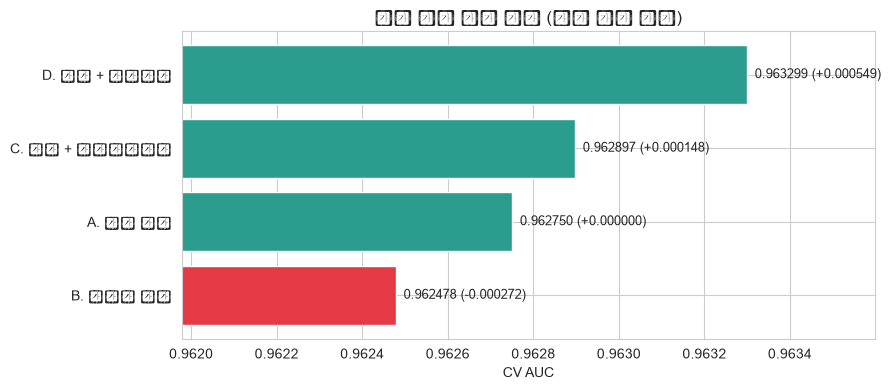

In [10]:
# 비교 결과 정리
cmp_df = log.to_frame()
print(cmp_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
d = cmp_df.sort_values('CV AUC')
colors = ['#2a9d8f' if v >= 0 else '#e63946' for v in d['베이스라인 대비']]
ax.barh(d['실험'], d['CV AUC'], color=colors)
ax.set_xlim(d['CV AUC'].min() - 0.0005, d['CV AUC'].max() + 0.0003)
ax.set_xlabel('CV AUC')
ax.set_title('결측 처리 전략 비교 (고속 설정 기준)')
for i, (v, dl) in enumerate(zip(d['CV AUC'], d['베이스라인 대비'])):
    ax.text(v, i, f'  {v:.6f} ({dl:+.6f})', va='center', fontsize=9)
plt.tight_layout(); plt.show()

### 해석 — 가설이 절반만 맞았다

**맞은 것: 중앙값 대치(B)는 손해였다.**
02단계에서 본 것처럼 인위적인 봉우리를 만들어 원래 분포를 왜곡하기 때문이다.
LightGBM에게는 "값이 없다"는 정보를 그대로 주는 편이 낫다.

**틀린 것: 결측 정보가 실제로는 도움이 됐다.**
01단계 EDA에서 "결측 여부에 따른 중독률 차이가 최대 0.42%p이므로
결측 표시 변수는 쓸모없을 것"이라고 예측했다. 그런데 실측해보니
**C와 D 모두 베이스라인보다 높았고, 특히 D(행별 결측 개수)가 가장 좋았다.**

### 왜 EDA 예측이 빗나갔나

EDA에서 본 것은 **"한 변수의 결측 여부"와 타깃의 1:1 관계**였다.
각각은 거의 0이었다. 하지만 모델이 쓰는 정보는 그것만이 아니다.

- **상호작용(interaction)**: "스크린타임이 8시간이면서 + 결측이 3개인 사람"처럼
  다른 변수와 **조합**될 때 의미가 생길 수 있다. 트리 모델은 이런 조합을
  자동으로 찾아내는데, 단변량 상관분석으로는 절대 보이지 않는다.
- **요약이 개별보다 나았다**: 12개의 개별 표시 변수(C)보다 이를 하나로 합친
  `n_missing`(D)이 더 좋았다. 열을 12개 늘리면 트리가 매번 그 열들을
  후보로 검토하느라 **정보는 희석되고 노이즈만 늘어난다.**

> **교훈 2가지**
> 1. **EDA는 가설을 만드는 단계지, 결론을 내는 단계가 아니다.** 단변량 분석으로
>    "쓸모없다"고 단정하고 버렸다면 이 이득을 놓쳤을 것이다. 최종 판단은 항상 CV다.
> 2. **피처는 많을수록 좋은 게 아니다.** C(24열)보다 D(13열)가 나았다.
>    같은 정보라면 **압축된 형태**가 유리하다.

### 단, 크기를 냉정하게 보자
개선폭은 소수점 넷째 자리(약 +0.0005)다. 폴드 간 표준편차와 비슷한 수준이라
**"확실한 개선"이라기보다 "약한 신호"** 로 보는 게 정직하다.
다만 모든 실험이 **같은 폴드 분할**을 쓴 짝지은 비교이므로,
단순한 우연보다는 신뢰할 만하다. 04단계에서 조합으로 재검증한다.

## 4. 피처 중요도 — 04단계 설계의 근거

In [11]:
# 전체 데이터로 모델 하나를 학습해 중요도를 본다.
# (폴드별 중요도를 평균내도 되지만, 경향 파악에는 하나로 충분하다)
imp_model = lgb.LGBMClassifier(**{**LGB_PARAMS,
                                  'n_estimators': int(np.mean(base['best_iters']))})
imp_model.fit(X, y)

# 중요도에는 두 종류가 있다:
#  - split : 그 변수가 분기 조건으로 몇 번 쓰였는가 (사용 빈도)
#  - gain  : 그 변수로 분기했을 때 손실이 얼마나 줄었는가 (실제 기여도) ★ 더 중요
imp = pd.DataFrame({
    '변수': X.columns,
    'gain': imp_model.booster_.feature_importance('gain'),
    'split': imp_model.booster_.feature_importance('split'),
})
imp['gain_비율(%)'] = (imp['gain'] / imp['gain'].sum() * 100).round(2)
imp = imp.sort_values('gain', ascending=False).reset_index(drop=True)
imp

,변수,gain,split,gain_비율(%)
0,daily_screen_time_hours,1.888460e+06,12733,38.18
1,weekend_screen_time,9.807805e+05,12181,19.83
2,social_media_hours,8.855742e+05,11809,17.90
3,notifications_per_day,3.734007e+05,14876,7.55
4,app_opens_per_day,3.328337e+05,13904,6.73
5,work_study_hours,1.776972e+05,11655,3.59
6,gaming_hours,1.496732e+05,11056,3.03
7,sleep_hours,8.326222e+04,10760,1.68
8,age,4.780848e+04,5746,0.97
9,stress_level,1.039983e+04,1692,0.21


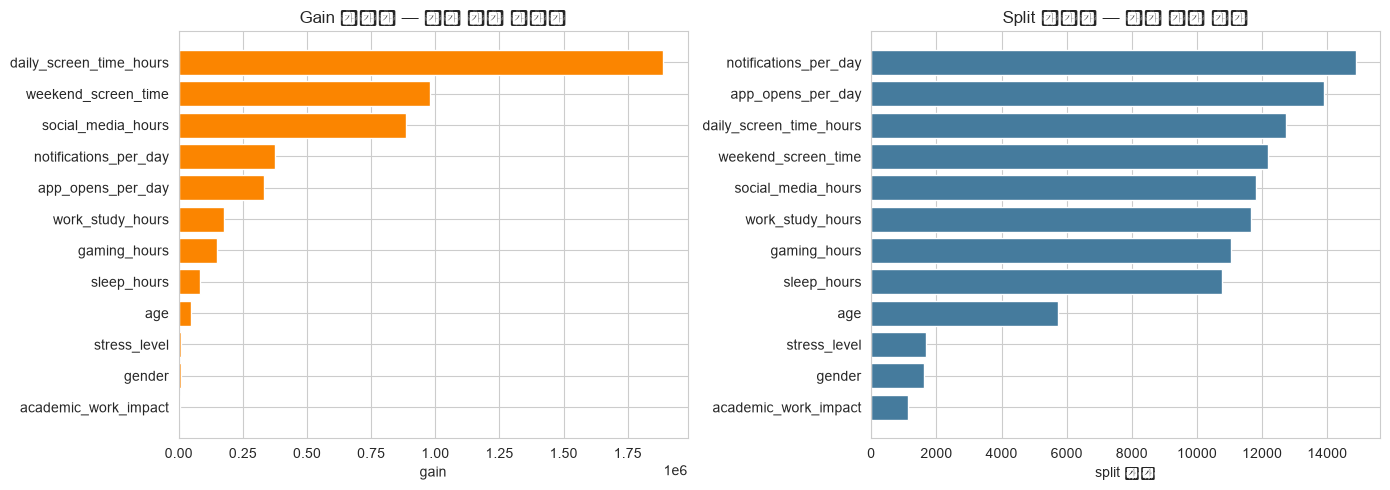

상위 3개 변수가 전체 gain의 75.9% 를 차지


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

d1 = imp.sort_values('gain')
axes[0].barh(d1['변수'], d1['gain'], color='#fb8500')
axes[0].set_title('Gain 중요도 — 실제 예측 기여도')
axes[0].set_xlabel('gain')

d2 = imp.sort_values('split')
axes[1].barh(d2['변수'], d2['split'], color='#457b9d')
axes[1].set_title('Split 중요도 — 분기 사용 횟수')
axes[1].set_xlabel('split 횟수')

plt.tight_layout(); plt.show()

top3 = imp.head(3)['gain_비율(%)'].sum()
print(f'상위 3개 변수가 전체 gain의 {top3:.1f}% 를 차지')

### 해석 — 04단계 파생변수 설계 힌트

`gain`과 `split`의 **순위가 다른 변수**를 주목하자.

- **gain은 낮은데 split은 높은 변수**: 자주 쓰이지만 성능 기여는 작다.
  → 다른 변수와 조합해서 **새 정보를 만들어낼 여지**가 있다.
- **gain이 압도적인 변수**: 이미 정보를 다 쓰고 있다.
  → 이 변수를 **다른 변수로 나누거나 빼서** 새로운 각도를 만들면 좋다.

01단계에서 `daily_screen_time`과 `weekend_screen_time`의 상관이 **0.80**으로
매우 높았다. 둘이 거의 같은 정보를 담고 있다는 뜻이다.
→ **비율(`weekend / daily`)** 을 만들면 "평일 대비 주말에 얼마나 더 쓰는가"라는
원본에 없던 **패턴 정보**가 생긴다. 04단계에서 이걸 검증한다.

## 5. 예측 품질 확인

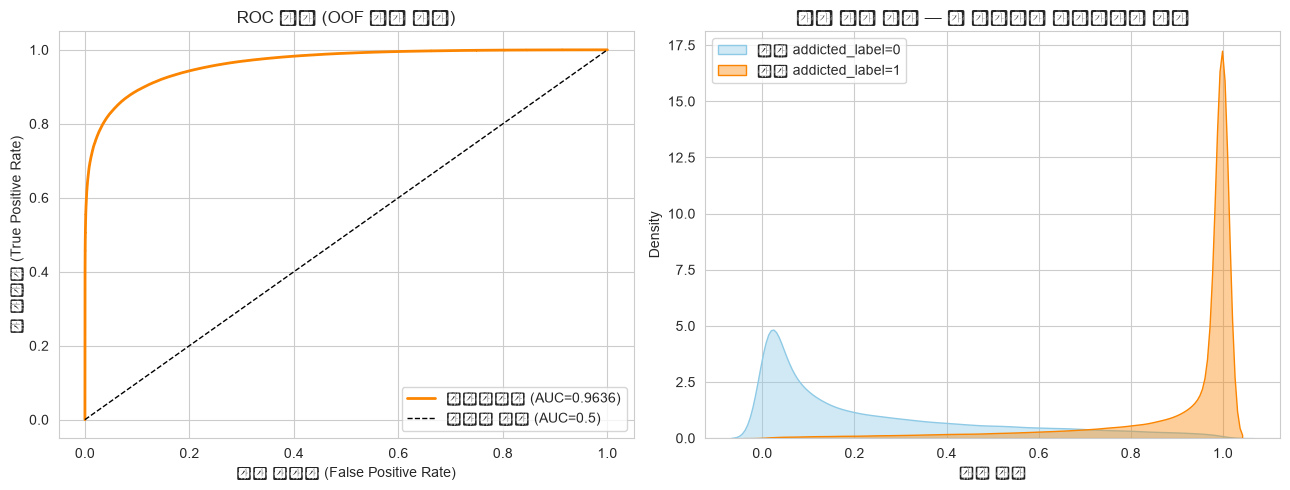

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── ROC 커브 ──
# 임계값을 0에서 1까지 바꿔가며 (거짓양성률, 참양성률)을 그린 곡선.
# 곡선 아래 면적이 AUC다. 왼쪽 위 모서리에 붙을수록 좋은 모델이다.
fpr, tpr, _ = roc_curve(y, base['oof'])
axes[0].plot(fpr, tpr, lw=2, color='#fb8500',
             label=f"베이스라인 (AUC={base['cv_auc']:.4f})")
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='무작위 추측 (AUC=0.5)')
axes[0].set_xlabel('거짓 양성률 (False Positive Rate)')
axes[0].set_ylabel('참 양성률 (True Positive Rate)')
axes[0].set_title('ROC 커브 (OOF 예측 기준)')
axes[0].legend(loc='lower right')

# ── 예측 확률 분포 ──
# 실제 0인 사람과 1인 사람의 예측값이 잘 갈라져 있는지 본다.
for label, color in [(0, '#8ecae6'), (1, '#fb8500')]:
    sns.kdeplot(base['oof'][y == label], ax=axes[1], fill=True, alpha=0.4,
                color=color, label=f'실제 {TARGET}={label}')
axes[1].set_xlabel('예측 확률')
axes[1].set_title('예측 확률 분포 — 두 봉우리가 갈라질수록 좋다')
axes[1].legend()

plt.tight_layout(); plt.show()

## 6. 결과 저장 — 05단계 앙상블 준비

In [14]:
import os
os.makedirs('../preds', exist_ok=True)

# OOF 예측: 앙상블 가중치를 찾을 때 '정답을 아는 검증 데이터'로 쓴다
np.save('../preds/oof_lgbm_base.npy', base['oof'])
# 테스트 예측: 5개 폴드 모델 예측의 평균
np.save('../preds/test_lgbm_base.npy', base['test_pred'])

print(f"저장 완료")
print(f"  OOF  shape={base['oof'].shape}  AUC={base['cv_auc']:.6f}")
print(f"  TEST shape={base['test_pred'].shape}  "
      f"평균={base['test_pred'].mean():.4f} (train 양성비율 {y.mean():.4f}와 비슷해야 정상)")

저장 완료
  OOF  shape=(691369,)  AUC=0.963574
  TEST shape=(296302,)  평균=0.7100 (train 양성비율 0.7094와 비슷해야 정상)


In [15]:
# 베이스라인 제출 파일도 만들어둔다.
# 리더보드 점수를 받아보면 "CV와 LB가 같은 방향으로 움직이는지" 확인할 수 있다.
os.makedirs('../submissions', exist_ok=True)
sub_base = sub.copy()
sub_base[TARGET] = base['test_pred']
sub_base.to_csv('../submissions/submission_v1_baseline.csv', index=False)

print(sub_base.head())
print()
print(f"제출 파일 저장: submissions/submission_v1_baseline.csv  ({len(sub_base):,} 행)")

       id  addicted_label
0  691369        0.999467
1  691370        0.961710
2  691371        0.959337
3  691372        0.989136
4  691373        0.998202

제출 파일 저장: submissions/submission_v1_baseline.csv  (296,302 행)


---
## 📌 03단계 요약

### 베이스라인 확정
아래 셀에서 실제 측정값을 출력한다. 이 점수가 앞으로 모든 비교의 기준이 된다.

### 확인한 것
1. **중앙값 대치는 손해** — 분포를 왜곡하므로 원본을 그대로 주는 게 낫다
2. **결측 정보는 도움이 됨 (EDA 가설과 반대)** — 단, 개별 표시 변수 12개보다
   **행별 결측 개수 1개로 압축**하는 편이 더 좋았다
3. **폴드 간 편차가 작음** → 검증 틀이 안정적이라 점수를 믿을 수 있음
4. **피처 중요도 확보** → 04단계 파생변수 설계의 근거

### 다음 단계 (04_feature_engineering)
- [ ] 주말/평일 비율 등 파생변수 5그룹 실험
- [ ] 도움이 되는 그룹만 선별 (많이 넣는다고 좋아지지 않음을 확인)
- [ ] `n_missing`을 최종 피처셋에 포함할지 조합으로 재검증
- [ ] Optuna 하이퍼파라미터 튜닝

In [16]:
print('=' * 58)
print(f"{'베이스라인 CV AUC':<26} {base['cv_auc']:.6f}")
print(f"{'폴드 평균 ± 표준편차':<25} {base['fold_mean']:.6f} ± {base['fold_std']:.6f}")
print(f"{'사용 피처 수':<27} {X.shape[1]}")
print(f"{'평균 트리 개수':<26} {int(np.mean(base['best_iters']))}")
print(f"{'학습 소요 시간':<26} {base['elapsed']:.1f}초")
print('=' * 58)
print()
print('결측 처리 전략 비교 (고속 설정):')
print(cmp_df.to_string(index=False))

베이스라인 CV AUC               0.963574
폴드 평균 ± 표준편차              0.963576 ± 0.000562
사용 피처 수                     12
평균 트리 개수                   1761
학습 소요 시간                   194.6초

결측 처리 전략 비교 (고속 설정):
            실험   CV AUC  베이스라인 대비              비고
  D. 원본 + 결측개수 0.963299  0.000549 결측 정보를 1개 열로 요약
C. 원본 + 결측표시변수 0.962897  0.000148      열 12 -> 24
      A. 원본 유지 0.962750  0.000000   LGBM 자체 결측 처리
     B. 중앙값 대치 0.962478 -0.000272 수치=중앙값 / 범주=최빈값
